<a href="https://colab.research.google.com/github/xuerongNanopay/ai_tut/blob/main/colab/LoRA_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
W_bp_loss = np.array([[4,3,2,1],
              [2,2,2,2],
              [1,3,4,2],
              [0,1,2,3]])

In [15]:
d = W_bp_loss.shape[0]

r = 2

A = np.random.rand(d, r)
B = np.zeros((r, d))


In [16]:
A

array([[0.98868684, 0.73058735],
       [0.56950864, 0.98597819],
       [0.41097099, 0.00165309],
       [0.09137032, 0.55258872]])

In [17]:
B

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [18]:
lr = 0.01

epochs = 1000

In [19]:
def loss_function(W, A, B):
    W_approx = A @ B
    return np.linalg.norm(W - W_approx, "fro")*2

In [20]:
def descent(W, A, B, lr, epochs):
    loss_history = []
    for i in range(epochs):
        W_approx = A @ B
        gd_A = -2 * (W - W_approx) @ B.T
        gd_B = -2 * A.T @ (W - W_approx)
        A -= lr * gd_A
        B -= lr * gd_B
        loss = loss_function(W, A, B)
        loss_history.append(loss)
        if i % 100 == 0:
            print(f"Epoch: {i}, Loss: {loss:.4f}")
    return A, B, loss_history

In [21]:
A, B, loss_history = descent(W, A, B, lr, epochs)

Epoch: 0, Loss: 18.2199
Epoch: 100, Loss: 3.1049
Epoch: 200, Loss: 3.0703
Epoch: 300, Loss: 3.0703
Epoch: 400, Loss: 3.0703
Epoch: 500, Loss: 3.0703
Epoch: 600, Loss: 3.0703
Epoch: 700, Loss: 3.0703
Epoch: 800, Loss: 3.0703
Epoch: 900, Loss: 3.0703


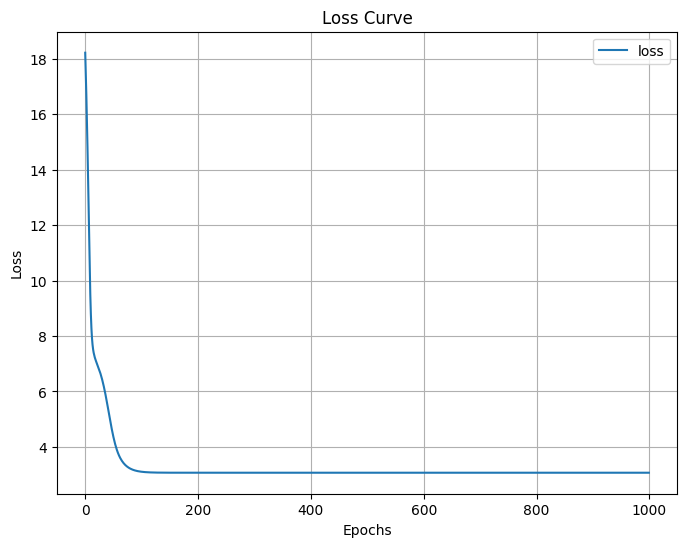

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(loss_history, label="loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
W_trained = A @ B
print(W_trained)

[[ 3.92499196  3.06584542  2.10616302  0.84487308]
 [ 1.80749375  2.16899061  2.27246474  1.60187065]
 [ 1.39233235  2.65559308  3.44471033  2.81139716]
 [-0.31000446  1.27213581  2.43876645  2.35886822]]


In [27]:
print(W_bp_loss)

[[4 3 2 1]
 [2 2 2 2]
 [1 3 4 2]
 [0 1 2 3]]
